In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Numpy fft
Usage of [Numpy fft](https://numpy.org/doc/stable/reference/routines.fft.html#module-numpy.fft) for real data

200


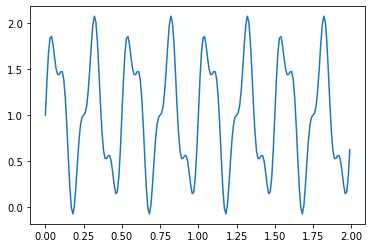

In [4]:
t = np.arange(0,2,0.01) # 2 seconds, 100 measurements per second
freq1 = 4 # 4 hz
freq2 = 10 # 10 hz
y = 1 + 0.8 * np.sin(2 * np.pi * t * freq1) + 0.3 * np.sin(2 * np.pi * t * freq2)
N = t.shape[-1]
print(N) # N measurement points
plt.plot(t, y)

# Vizualize the signal main frequencies
- Compute the fourier transform
- Numpy fftfreq helper computes the various frequencies (rfftfreq for real, no negative frequencies)
- Plot the fft against the frequencies
- The spike a f=0 is the main amplitude of the signal
- Smaller spikes at f=4 and f=10 Hz with amplitudes 0.8 and 0.3
- TODO: The amplitude for f=4 and f=10 is off by a factor 2, explain (maybe due to rfft not having the negative frequencies that would sum up ?)

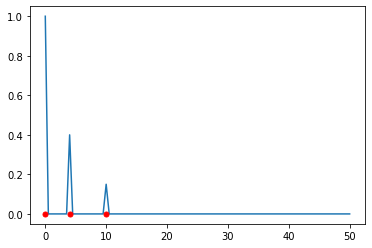

In [5]:
fft = np.fft.rfft(y)

freq = np.fft.rfftfreq(N, d=0.01)
plt.plot(freq, abs(fft)/N)
plt.plot(0, 0, marker='o', markersize=5, color="red")
plt.plot(freq1, 0, marker='o', markersize=5, color="red")
plt.plot(freq2, 0, marker='o', markersize=5, color="red")

# Find the max frequencies in the fft array
Using numpy argsort

In [10]:
absfft = abs(fft)
idx1 = np.argsort(absfft)[-1]
idx2 = np.argsort(absfft)[-2]
idx3 = np.argsort(absfft)[-3]
freq1 = freq[idx1]
freq2 = freq[idx2]
freq3 = freq[idx3]
print("frequencies : ", [freq1, freq2, freq3])

frequencies :  [0.0, 4.0, 10.0]


# Retrieve the original signal
- Compute the inverse fft with numpy ifft function

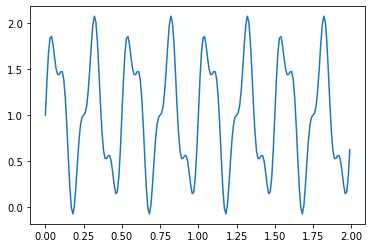

In [6]:
inverse_fft = np.fft.irfft(fft)

plt.plot(t, inverse_fft)